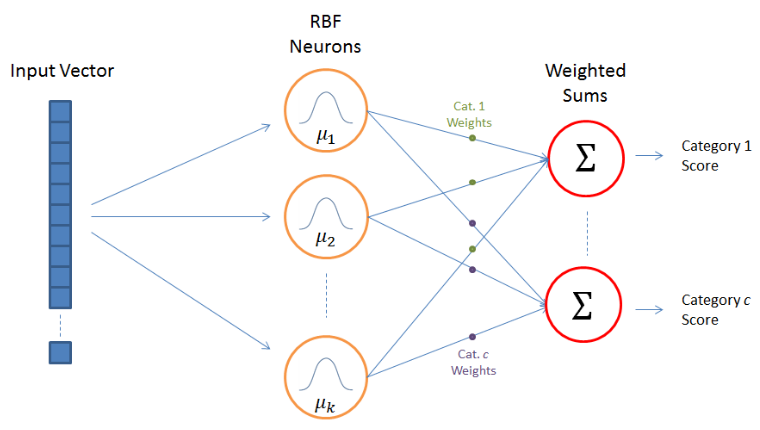

In [153]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from ucimlrepo import fetch_ucirepo 

In [154]:
iris = fetch_ucirepo(id=53)
X = iris.data.features 
y = iris.data.targets

In [155]:
mapping = {
    'Iris-setosa': 0,
    'Iris-versicolor': 1,
    'Iris-virginica': 2
}
y_numeric = y['class'].map(mapping)
type(y_numeric)

pandas.core.series.Series

In [156]:
scaler = StandardScaler()

In [157]:
X = scaler.fit_transform(X)

In [158]:
X_train, X_test, y_train, y_test = train_test_split(X, y_numeric, test_size=0.3, random_state=42)

In [159]:
def to_tensor(data, target):
    return torch.tensor(data=data, dtype=torch.float32), torch.tensor(data=target.values, dtype=torch.float32)

In [160]:
X_train, y_train = to_tensor(X_train, y_train)
X_test, y_test = to_tensor(X_test, y_test)

In [161]:
y_train = y_train.long()
y_test = y_test.long()

In [162]:
def rbf_kernel(x, center, beta):
    return torch.exp(-beta * torch.cdist(x, center) ** 2)

In [163]:
class RBFN(nn.Module):

    def __init__(self, input_dim, num_centers, output_dim):
        super(RBFN, self).__init__()
        self.centers = nn.Parameter(torch.randn(num_centers, input_dim))
        self.beta = nn.Parameter(torch.ones(1) * 2.0)
        self.linear = nn.Linear(in_features=num_centers, out_features=output_dim)

    def forward(self, x):

        phi = rbf_kernel(x, self.centers, self.beta)
        return self.linear(phi)


In [164]:
num_centers = 10
model = RBFN(input_dim=4, num_centers=10, output_dim=3)

In [165]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(params=model.parameters(), lr=0.01)

In [166]:
num_epochs = 10000
for epoch in range(num_epochs):
    optimizer.zero_grad()
    output = model(X_train)
    loss = criterion(output, y_train)
    loss.backward()
    optimizer.step()

    if (epoch+1) % 4 == 0:
        print(f"Epcoh {epoch + 1} / {num_epochs}, Loss: {loss.item():.4f}")

Epcoh 4 / 10000, Loss: 1.1106
Epcoh 8 / 10000, Loss: 1.1016
Epcoh 12 / 10000, Loss: 1.0946
Epcoh 16 / 10000, Loss: 1.0883
Epcoh 20 / 10000, Loss: 1.0816
Epcoh 24 / 10000, Loss: 1.0732
Epcoh 28 / 10000, Loss: 1.0618
Epcoh 32 / 10000, Loss: 1.0458
Epcoh 36 / 10000, Loss: 1.0238
Epcoh 40 / 10000, Loss: 0.9946
Epcoh 44 / 10000, Loss: 0.9571
Epcoh 48 / 10000, Loss: 0.9108
Epcoh 52 / 10000, Loss: 0.8561
Epcoh 56 / 10000, Loss: 0.7944
Epcoh 60 / 10000, Loss: 0.7276
Epcoh 64 / 10000, Loss: 0.6583
Epcoh 68 / 10000, Loss: 0.5897
Epcoh 72 / 10000, Loss: 0.5248
Epcoh 76 / 10000, Loss: 0.4653
Epcoh 80 / 10000, Loss: 0.4117
Epcoh 84 / 10000, Loss: 0.3647
Epcoh 88 / 10000, Loss: 0.3244
Epcoh 92 / 10000, Loss: 0.2906
Epcoh 96 / 10000, Loss: 0.2624
Epcoh 100 / 10000, Loss: 0.2391
Epcoh 104 / 10000, Loss: 0.2196
Epcoh 108 / 10000, Loss: 0.2032
Epcoh 112 / 10000, Loss: 0.1894
Epcoh 116 / 10000, Loss: 0.1777
Epcoh 120 / 10000, Loss: 0.1677
Epcoh 124 / 10000, Loss: 0.1589
Epcoh 128 / 10000, Loss: 0.1511
Ep

In [167]:
with torch.no_grad():
    y_pred = model(X_test)
    accuracy = (torch.argmax(y_pred, axis=1) == y_test).float().mean().item()

    print(f"Accuracy: {accuracy}")

Accuracy: 0.9777777791023254
